# Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to produce a more accurate and robust model.

It can be used for:

- Classification
- Regression

Random Forest improves upon a single Decision Tree mainly by reducing variance and preventing overfitting.

---

## Core Idea

Instead of training one Decision Tree on the entire dataset, Random Forest:

1. Creates many bootstrap samples from the training data.
2. Trains a separate Decision Tree on each bootstrap sample.
3. Randomly selects a subset of features at every tree split.
4. Combines the predictions of all trees.

For classification:

$$
\hat{y} = \text{Majority Vote}(T_1(x), T_2(x), \dots, T_B(x))
$$

For regression:

$$
\hat{y} = \frac{1}{B}\sum_{b=1}^{B} T_b(x)
$$

where:

- $B$ = number of trees
- $T_b$ = the $b$-th Decision Tree
- $x$ = input sample
- $\hat{y}$ = final prediction

## Why Random Forest?

A single Decision Tree can easily overfit the training data.

For example, a deep Decision Tree may learn:

- Noise
- Outliers
- Small patterns specific to the training data

This produces a model with low bias but high variance.

Random Forest solves this problem by averaging many different trees.

The important idea is:

> Many diverse trees working together are usually more reliable than one highly flexible tree.

Random Forest creates diversity using two main mechanisms:

1. Bootstrap Sampling
2. Random Feature Selection

## Bootstrap Sampling

Bootstrap sampling means creating a new training dataset by randomly sampling observations from the original training dataset **with replacement**.

Suppose the original dataset contains:

$$
n
$$

observations.

A bootstrap sample also contains approximately:

$$
n
$$

observations, but some observations may appear multiple times while others may not appear at all.

Example:

Original dataset:

$$
[1,2,3,4,5]
$$

Possible bootstrap sample:

$$
[2,5,2,1,4]
$$

Here:

- 2 appears twice
- 3 does not appear
- Other observations appear once

Each Decision Tree receives a different bootstrap sample.

This makes the trees different from one another.

## Why Sampling With Replacement?

Sampling with replacement creates different datasets for different trees.

For example:

Tree 1:

$$
[1,2,2,4,5]
$$

Tree 2:

$$
[1,1,3,4,5]
$$

Tree 3:

$$
[2,3,3,4,5]
$$

Because each tree sees a different dataset, the trees make somewhat different predictions.

This diversity is important for reducing variance.

## Random Feature Selection

Random Forest does not allow every Decision Tree to consider all features at every split.

Instead, it randomly selects a subset of features.

Suppose a dataset has:

$$
d = 10
$$

features.

At a particular split, the tree might consider only:

$$
m = 3
$$

randomly selected features.

The best split is then selected only from these 3 features.

At another node, a different subset of features is selected.

This creates additional diversity between trees.

## Why Random Features?

Suppose one feature is extremely strong.

If every tree always considers that feature, many trees may become very similar.

Highly correlated trees provide less benefit when their predictions are combined.

Random feature selection forces trees to explore different patterns.

Therefore:

$$
\text{Random Sampling}
+
\text{Random Features}
\rightarrow
\text{Diverse Trees}
$$

and

$$
\text{Diverse Trees}
+
\text{Aggregation}
\rightarrow
\text{Lower Variance}
$$

## Random Forest Architecture

The Random Forest training process can be summarized as:

$$
\text{Original Dataset}
$$

$$
\downarrow
$$

$$
\text{Bootstrap Samples}
$$

$$
\downarrow
$$

$$
\begin{cases}
\text{Decision Tree}_1 \\
\text{Decision Tree}_2 \\
\text{Decision Tree}_3 \\
\vdots \\
\text{Decision Tree}_B
\end{cases}
$$

$$
\downarrow
$$

$$
\text{Combine Predictions}
$$

$$
\downarrow
$$

$$
\text{Final Prediction}
$$

## Random Forest for Classification

For classification, every Decision Tree produces a class prediction.

Suppose there are 5 trees:

| Tree | Prediction |
|------|------------|
| Tree 1 | Class A |
| Tree 2 | Class B |
| Tree 3 | Class A |
| Tree 4 | Class A |
| Tree 5 | Class B |

The predictions are:

$$
[A,B,A,A,B]
$$

Class A receives 3 votes.

Class B receives 2 votes.

Therefore:

$$
\hat{y} = A
$$

This is called **majority voting**.

## Classification Probability

Random Forest can also produce class probabilities.

The probability of class $k$ can be estimated from the proportion of trees voting for that class:

$$
P(y=k|x)
=
\frac{1}{B}
\sum_{b=1}^{B}
I(T_b(x)=k)
$$

where:

- $B$ = number of trees
- $T_b(x)$ = prediction of tree $b$
- $I(\cdot)$ = indicator function

For example, if 80 out of 100 trees predict Class 1:

$$
P(y=1|x)=\frac{80}{100}=0.80
$$

## Random Forest for Regression

For regression, Random Forest combines predictions by averaging them.

Suppose 5 trees produce:

$$
[10,12,11,13,14]
$$

The final prediction is:

$$
\hat{y}
=
\frac{10+12+11+13+14}{5}
$$

$$
\hat{y}=12
$$

Therefore:

> Classification → Majority Vote

> Regression → Average

## Bagging vs Random Forest

Random Forest is closely related to Bagging.

### Bagging

Bagging typically:

- Creates bootstrap samples
- Trains one model on each sample
- Uses the same complete feature set

### Random Forest

Random Forest:

- Creates bootstrap samples
- Trains many Decision Trees
- Randomly selects features at each split

Therefore, Random Forest introduces an additional source of randomness.

$$
\text{Random Forest}
=
\text{Bagging}
+
\text{Random Feature Selection}
$$

## Random Forest vs Decision Tree

| Property | Decision Tree | Random Forest |
|---|---|---|
| Number of trees | 1 | Many |
| Bootstrap sampling | Usually no | Yes |
| Random feature selection | No | Yes |
| Variance | High | Lower |
| Overfitting | More likely | Less likely |
| Interpretability | High | Lower |
| Training time | Lower | Higher |
| Prediction time | Lower | Higher |
| Accuracy | Often lower | Often higher |

Random Forest sacrifices some interpretability and computational efficiency in exchange for better generalization.

## Mathematical Intuition: Variance Reduction

Suppose each tree has variance:

$$
\sigma^2
$$

If the trees were completely independent, averaging $B$ trees would produce approximately:

$$
Var(\bar{T})
=
\frac{\sigma^2}{B}
$$

Therefore, increasing the number of trees can substantially reduce variance.

However, Random Forest trees are not completely independent.

They are correlated because they are trained on the same original dataset.

If the pairwise correlation between trees is $\rho$, an approximate variance expression is:

$$
Var(\bar{T})
=
\rho\sigma^2
+
\frac{1-\rho}{B}\sigma^2
$$

This explains an important idea:

> Random Forest benefits from both a large number of trees and low correlation between trees.

Random feature selection helps reduce correlation between trees.

## Important Random Forest Hyperparameters

### 1. `n_estimators`

Number of Decision Trees.

Example:

```python
RandomForestClassifier(n_estimators=100)

More trees generally improve stability, but increase computation.

## 2. max_depth

Maximum depth of each Decision Tree.

```text
Smaller values:

Reduce complexity
Reduce overfitting
Increase bias

Larger values:

Increase model flexibility
Can increase overfitting

### 3. max_features

Number of features considered at each split.

```text
Examples:

max_features="sqrt"
max_features="log2"
max_features=None

Smaller feature subsets create more diverse trees.

### 4. min_samples_split

Minimum number of samples required to split a node.

## 5. min_samples_leaf

Minimum number of samples allowed in a leaf.

## 6. bootstrap

```text
Whether bootstrap samples are used.

bootstrap=True

is the traditional Random Forest approach.

## 7. criterion

The splitting criterion.

```text
For classification, common choices include:

criterion="gini"
criterion="entropy"
criterion="log_loss"

For regression:

criterion="squared_error"
criterion="absolute_error"


---


# Random Forest Classification

We will build a Random Forest classifier using the Breast Cancer dataset.

The workflow will be:

1. Load dataset
2. Explore dataset
3. Split into training and testing sets
4. Train Random Forest
5. Make predictions
6. Evaluate the model
7. Visualize feature importance
8. Analyze the effect of the number of trees

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))

print("\nClass names:")
print(data.target_names)

Number of samples: 569
Number of features: 30
Number of classes: 2

Class names:
['malignant' 'benign']


## Train-Test Split

We split the dataset into:

- Training set → used to train the Random Forest
- Test set → used to evaluate generalization

We use `stratify=y` so that the class distribution is approximately preserved in both sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## Train Random Forest

In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Making Predictions

After training, the Random Forest contains 100 Decision Trees.

For a new sample:

1. Every tree makes a prediction.
2. The predictions are collected.
3. The majority class becomes the final prediction.

In [6]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0])

## Model Evaluation

In [7]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104


In [8]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Confusion Matrix

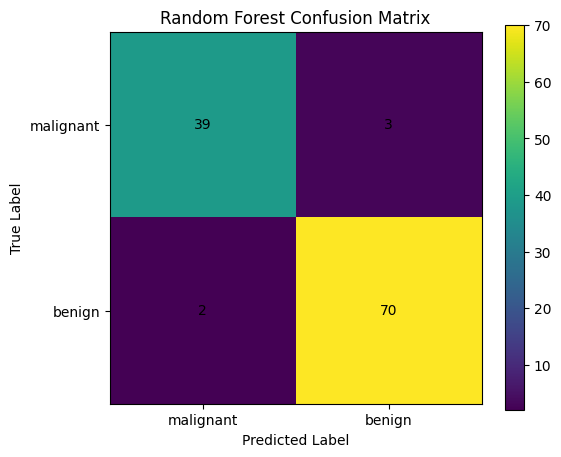

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")

plt.xticks(
    range(len(data.target_names)),
    data.target_names
)

plt.yticks(
    range(len(data.target_names)),
    data.target_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

# Feature Importance

Random Forest can estimate the importance of each feature.

A feature receives a higher importance score when it contributes more to reducing impurity across the trees.

The importance values satisfy approximately:

$$
\sum_{j=1}^{d} Importance_j = 1
$$

Feature importance can help us understand which variables are most useful for prediction.

However, feature importance should not automatically be interpreted as causality.

In [10]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(10)

worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
mean perimeter          0.069574
mean radius             0.068676
mean concavity          0.057638
mean area               0.049172
worst concavity         0.034340
dtype: float64

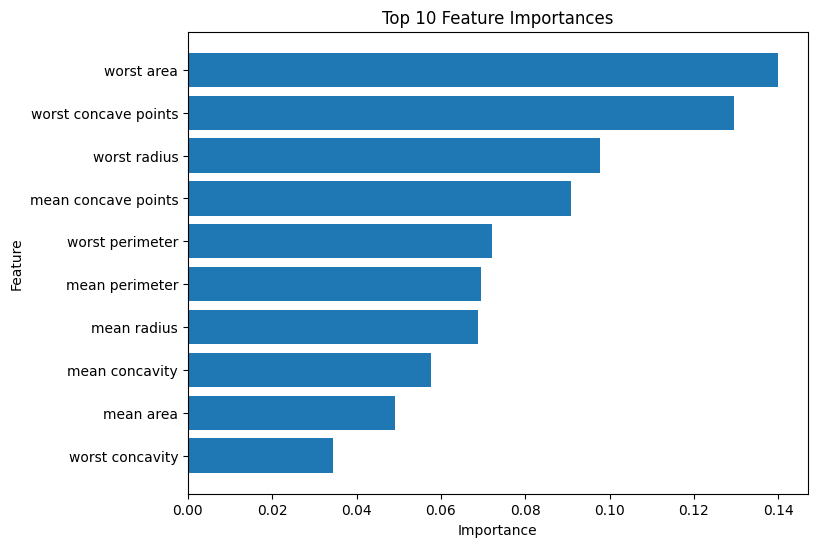

In [11]:
top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(8, 6))

plt.barh(
    top_features.index,
    top_features.values
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.show()

# Effect of Number of Trees

The `n_estimators` parameter controls the number of trees in the Random Forest.

We can train multiple Random Forest models and observe how accuracy changes.

Typical behavior:

- Very few trees → less stable
- More trees → more stable
- Extremely large number of trees → increased computation
- After a certain point → performance usually stabilizes

In [12]:
tree_counts = [1, 5, 10, 25, 50, 100, 200, 300]

accuracies = []

for n in tree_counts:

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf.fit(X_train, y_train)

    predictions = rf.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, predictions)
    )

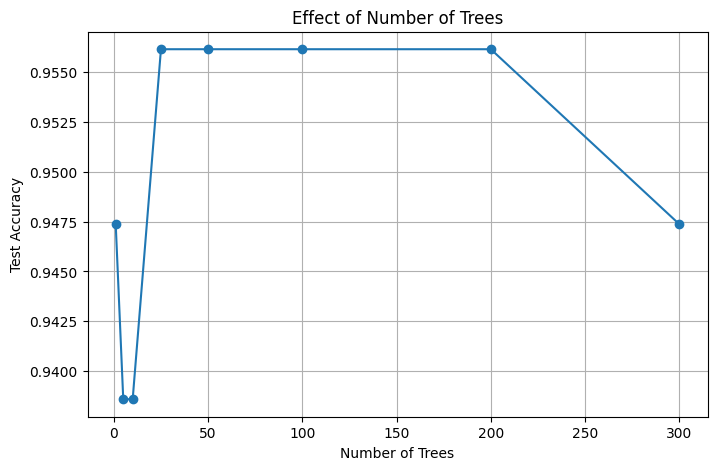

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    tree_counts,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.title("Effect of Number of Trees")

plt.grid(True)
plt.show()

# Out-of-Bag Evaluation

Random Forest uses bootstrap sampling.

Because sampling is done with replacement, some observations are not selected for a particular tree.

These observations are called **Out-of-Bag (OOB)** samples for that tree.

On average, approximately:

$$
36.8\%
$$

of the training observations are not included in a bootstrap sample.

These OOB observations can be used to evaluate the model.

This provides an internal validation estimate without requiring a separate validation set for that purpose.

In [14]:
oob_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    bootstrap=True,
    oob_score=True
)

oob_model.fit(X_train, y_train)

print("OOB Score:", oob_model.oob_score_)
print("Test Accuracy:", oob_model.score(X_test, y_test))

OOB Score: 0.9604395604395605
Test Accuracy: 0.956140350877193


# Random Forest Regression

Random Forest can also solve regression problems.

For regression, each tree predicts a numerical value.

The final prediction is the average of the tree predictions:

$$
\hat{y}
=
\frac{1}{B}
\sum_{b=1}^{B}
T_b(x)
$$

We will use the Diabetes dataset as an example.

In [15]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [16]:
diabetes = load_diabetes()

X_reg = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

y_reg = pd.Series(
    diabetes.target,
    name="target"
)

X_reg.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [17]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [18]:
regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

regressor.fit(
    X_train_reg,
    y_train_reg
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
y_pred_reg = regressor.predict(X_test_reg)

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_reg
    )
)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 44.276123595505624
RMSE: 54.461217375612414
R²  : 0.4401775677972706


## Actual vs Predicted

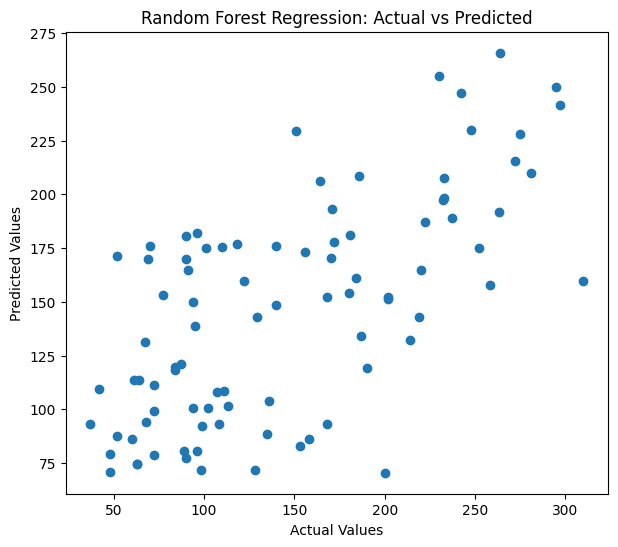

In [20]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_reg,
    y_pred_reg
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression: Actual vs Predicted")

plt.show()

# Visualizing Bootstrap Sampling

Random Forest creates different datasets for different trees using sampling with replacement.

Let's visualize this process.

Suppose our original dataset contains 20 observations.

Each tree receives a bootstrap sample of the same size, but some observations may appear multiple times while others may not appear.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_samples = 20

original_data = np.arange(n_samples)

bootstrap_sample = np.random.choice(
    original_data,
    size=n_samples,
    replace=True
)

print("Original data:")
print(original_data)

print("\nBootstrap sample:")
print(bootstrap_sample)

Original data:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Bootstrap sample:
[ 6 19 14 10  7  6 18 10 10  3  7  2  1 11  5  1  0 11 11 16]


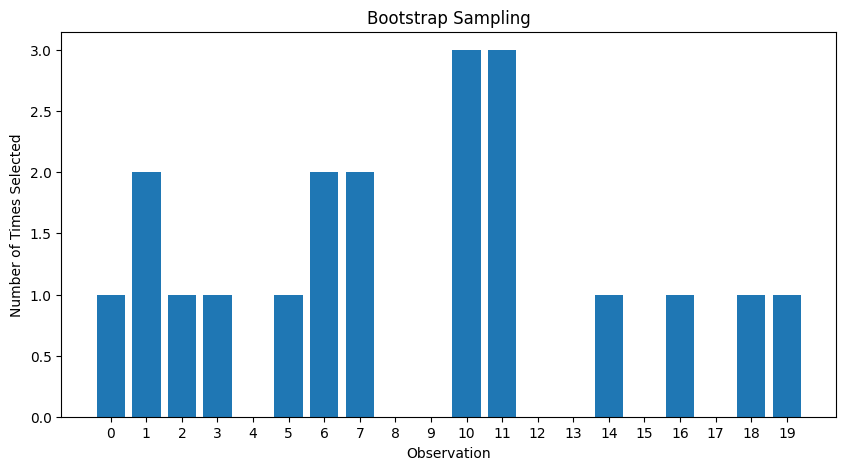

In [22]:
unique, counts = np.unique(
    bootstrap_sample,
    return_counts=True
)

plt.figure(figsize=(10, 5))

plt.bar(
    unique,
    counts
)

plt.xlabel("Observation")
plt.ylabel("Number of Times Selected")
plt.title("Bootstrap Sampling")

plt.xticks(original_data)

plt.show()

# Out-of-Bag Observations

Some observations are not selected during bootstrap sampling.

These observations are called **Out-of-Bag (OOB)** observations for that particular tree.

We can identify them:

$$
OOB = Original\ Observations - Bootstrap\ Observations
$$

In [23]:
oob_samples = np.setdiff1d(
    original_data,
    bootstrap_sample
)

print("Bootstrap sample:")
print(bootstrap_sample)

print("\nOut-of-Bag observations:")
print(oob_samples)

Bootstrap sample:
[ 6 19 14 10  7  6 18 10 10  3  7  2  1 11  5  1  0 11 11 16]

Out-of-Bag observations:
[ 4  8  9 12 13 15 17]


# Multiple Decision Trees

A Random Forest contains many Decision Trees.

Each tree is trained using:

- A different bootstrap sample
- Different randomly selected features

Therefore, the trees are intentionally different.

The goal is not to create identical powerful trees.

The goal is to create **diverse trees whose errors are less correlated**.

In [24]:
from sklearn.tree import DecisionTreeClassifier

trees = []

for i in range(5):

    tree = DecisionTreeClassifier(
        max_depth=3,
        random_state=i
    )

    tree.fit(X_train, y_train)

    trees.append(tree)

print("Number of trees:", len(trees))

Number of trees: 5


# Individual Tree vs Random Forest

A useful experiment is to compare individual Decision Trees with the complete Random Forest.

Individual trees can produce different predictions because they are trained on different samples.

The Random Forest combines these predictions to obtain a more stable result.

In [25]:
tree_accuracies = []

for tree in trees:

    predictions = tree.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    tree_accuracies.append(accuracy)

print("Individual tree accuracies:")
print(tree_accuracies)

print("\nRandom Forest accuracy:")
print(accuracy_score(y_test, y_pred))

Individual tree accuracies:
[0.9385964912280702, 0.9385964912280702, 0.9385964912280702, 0.9385964912280702, 0.9385964912280702]

Random Forest accuracy:
0.956140350877193


# Hyperparameter Tuning

Random Forest has several important hyperparameters.

The most important ones include:

- `n_estimators`
- `max_depth`
- `max_features`
- `min_samples_split`
- `min_samples_leaf`

Instead of manually testing every combination, we can use cross-validation.

We will use `RandomizedSearchCV` to search through multiple combinations efficiently.

In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "max_features": ["sqrt", "log2", None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [27]:
rf = RandomForestClassifier(
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

In [28]:
print("Best parameters:")

print(random_search.best_params_)

print("\nBest cross-validation score:")

print(random_search.best_score_)

Best parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}

Best cross-validation score:
0.9604395604395606


In [29]:
best_model = random_search.best_estimator_

best_predictions = best_model.predict(X_test)

print(
    "Test Accuracy:",
    accuracy_score(y_test, best_predictions)
)

Test Accuracy: 0.956140350877193


# Why Use Cross-Validation?

Suppose we evaluate a model using only one validation split.

The result can depend heavily on which observations happen to be in that split.

With $k$-fold cross-validation:

$$
CV\ Score
=
\frac{1}{k}
\sum_{i=1}^{k}
Score_i
$$

For example, with 5-fold cross-validation:

$$
CV\ Score
=
\frac{
Score_1+
Score_2+
Score_3+
Score_4+
Score_5
}{5}
$$

This gives a more reliable estimate of model performance.

Random Forest hyperparameters can therefore be tuned using cross-validation.

# Effect of Maximum Tree Depth

`max_depth` controls how deep each Decision Tree can grow.

Small depth:

$$
\text{Simple Model}
\rightarrow
\text{Higher Bias}
$$

Large depth:

$$
\text{Complex Model}
\rightarrow
\text{Potentially Higher Variance}
$$

Let's observe how depth affects test performance.

In [30]:
depths = [2, 3, 5, 8, 10, 15, None]

depth_accuracies = []

for depth in depths:

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )

    rf.fit(X_train, y_train)

    predictions = rf.predict(X_test)

    depth_accuracies.append(
        accuracy_score(y_test, predictions)
    )

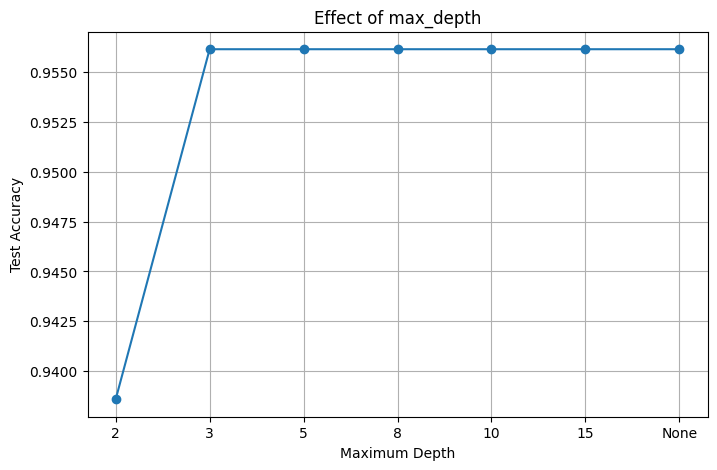

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(len(depths)),
    depth_accuracies,
    marker="o"
)

plt.xticks(
    range(len(depths)),
    [str(depth) for depth in depths]
)

plt.xlabel("Maximum Depth")
plt.ylabel("Test Accuracy")
plt.title("Effect of max_depth")

plt.grid(True)

plt.show()

# Effect of `max_features`

`max_features` controls how many features are considered when searching for the best split.

Smaller values:

- Increase randomness
- Increase tree diversity
- Can increase bias

Larger values:

- Make individual trees stronger
- Can increase correlation between trees

In [32]:
feature_options = [
    "sqrt",
    "log2",
    None
]

feature_accuracies = []

for option in feature_options:

    rf = RandomForestClassifier(
        n_estimators=200,
        max_features=option,
        random_state=42
    )

    rf.fit(X_train, y_train)

    predictions = rf.predict(X_test)

    feature_accuracies.append(
        accuracy_score(y_test, predictions)
    )

print(
    pd.DataFrame({
        "max_features": feature_options,
        "accuracy": feature_accuracies
    })
)

  max_features  accuracy
0         sqrt  0.956140
1         log2  0.956140
2          NaN  0.947368


# Permutation Feature Importance

Random Forest provides impurity-based feature importance through:

```python
model.feature_importances_

However, impurity-based importance can sometimes be misleading.

An alternative is Permutation Feature Importance.

The basic idea:

Measure the original model performance.
Randomly shuffle one feature.
Measure performance again.
Observe how much performance decreases.

If shuffling a feature causes a large performance drop, that feature is likely important.

Conceptually:

Importancej​=Scoreoriginal​−Scorepermuted,j​

In [33]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_importance_values = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(
    ascending=False
)

permutation_importance_values.head(10)

compactness error       0.007895
mean concave points     0.007895
worst texture           0.007018
worst area              0.007018
mean area               0.005263
mean smoothness         0.005263
radius error            0.004386
mean radius             0.004386
concave points error    0.003509
mean concavity          0.003509
dtype: float64

## Visualize Permutation Importance

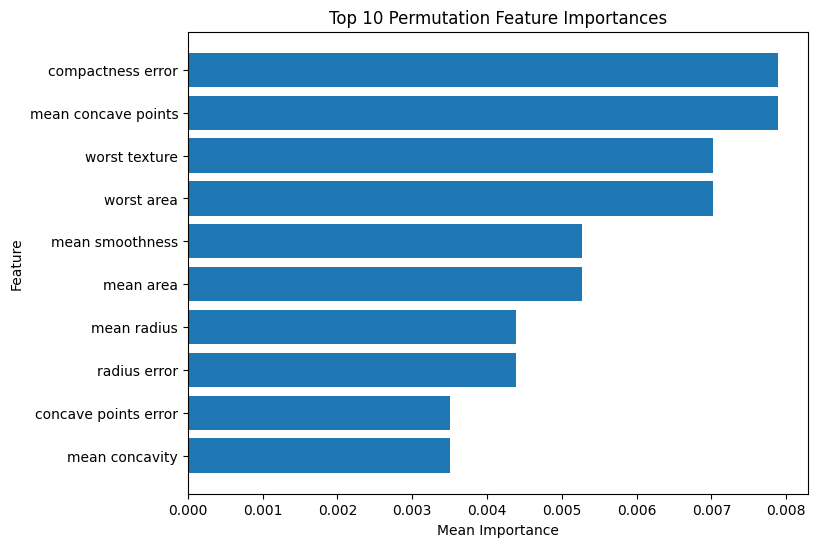

In [34]:
top_permutation = (
    permutation_importance_values
    .head(10)
    .sort_values()
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_permutation.index,
    top_permutation.values
)

plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.title("Top 10 Permutation Feature Importances")

plt.show()

# Impurity Importance vs Permutation Importance

| Method | Idea | Advantage | Limitation |
|---|---|---|---|
| Impurity Importance | Measures impurity reduction | Fast | Can be biased |
| Permutation Importance | Measures performance decrease after shuffling | More directly related to predictive performance | More computationally expensive |

Therefore:

```python
model.feature_importances_

is useful for a quick overview.

Permutation importance is often preferable when we want a more performance-oriented interpretation.


---


# Important Warning About Feature Importance

Feature importance does **not** mean causality.

Suppose:

$$
Feature\ A
$$

has high importance.

This means that the feature is useful for prediction under the model.

It does not prove:

$$
Feature\ A
\rightarrow
Target
$$

in a causal sense.

A feature can be important because:

- It is correlated with another useful feature.
- It contains indirect information.
- It acts as a proxy for another variable.
- It captures a statistical pattern in the dataset.

Therefore, feature importance should be interpreted carefully.

# Random Forest and the Bias-Variance Tradeoff

A Decision Tree can have:

$$
Low\ Bias + High\ Variance
$$

Random Forest reduces variance by averaging multiple trees.

Therefore, conceptually:

$$
\boxed{
Random\ Forest
\rightarrow
Variance\ Reduction
}
$$

Random Forest does not eliminate bias completely.

Instead, it provides a practical balance:

$$
\text{Reasonable Bias}
+
\text{Lower Variance}
\rightarrow
\text{Better Generalization}
$$

This connects Random Forest directly to the Bias-Variance Tradeoff studied earlier.

# Common Mistakes

### Mistake 1: Assuming More Trees Always Improve Accuracy

Increasing `n_estimators` generally improves stability, but eventually performance reaches a plateau.

---

### Mistake 2: Scaling Features Unnecessarily

Random Forest usually does not require feature scaling.

---

### Mistake 3: Using the Test Set for Hyperparameter Tuning

The test set should be reserved for final evaluation.

Use cross-validation on the training data for tuning.

---

### Mistake 4: Treating Feature Importance as Causality

Feature importance describes predictive usefulness, not causal relationships.

---

### Mistake 5: Using Extremely Deep Trees Without Checking Generalization

Random Forest is resistant to overfitting, but hyperparameters still matter.

---

### Mistake 6: Ignoring Class Imbalance

For imbalanced classification problems, accuracy may be misleading.

Consider:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- `class_weight`

# Handling Class Imbalance

Random Forest can handle class imbalance using:

```python
class_weight="balanced"

Example:

balanced_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(
    X_train,
    y_train
)

For imbalanced problems, model evaluation should focus on appropriate metrics rather than accuracy alone.


---


# Complete Random Forest Workflow

Let's combine the important steps into a practical workflow.

The general process is:

$$
\text{Data}
\rightarrow
\text{Split}
\rightarrow
\text{Random Forest}
\rightarrow
\text{Cross-Validation}
\rightarrow
\text{Hyperparameter Tuning}
\rightarrow
\text{Final Evaluation}
$$

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf = RandomForestClassifier(
    random_state=42
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_distributions,
    n_iter=15,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

final_model = search.best_estimator_

final_predictions = final_model.predict(X_test)

print("Best Parameters:")
print(search.best_params_)

print("\nTest Accuracy:")
print(accuracy_score(y_test, final_predictions))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=data.target_names
    )
)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15}

Test Accuracy:
0.956140350877193

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# Random Forest Checklist

Before using Random Forest on a new dataset:

### Data

- [ ] Handle missing values appropriately.
- [ ] Encode categorical variables when necessary.
- [ ] Check class imbalance.
- [ ] Split data correctly.

### Model

- [ ] Choose an appropriate number of trees.
- [ ] Consider `max_depth`.
- [ ] Consider `max_features`.
- [ ] Consider `min_samples_leaf`.
- [ ] Consider `class_weight` for imbalanced classification.

### Validation

- [ ] Use cross-validation for tuning.
- [ ] Keep the test set untouched until final evaluation.
- [ ] Consider OOB evaluation.

### Interpretation

- [ ] Examine feature importance.
- [ ] Consider permutation importance.
- [ ] Do not interpret feature importance as causality.

### Evaluation

For classification:

- [ ] Accuracy
- [ ] Precision
- [ ] Recall
- [ ] F1-score
- [ ] Confusion Matrix
- [ ] ROC-AUC / PR-AUC when appropriate

For regression:

- [ ] MAE
- [ ] RMSE
- [ ] R²

# Advantages of Random Forest

### 1. Reduces Overfitting

Combining many trees generally reduces the variance of a single Decision Tree.

### 2. Strong Performance

Random Forest often performs very well on tabular datasets.

### 3. Handles Nonlinear Relationships

It can learn complex nonlinear relationships without requiring explicit transformations.

### 4. Handles Feature Interactions

Random Forest can automatically capture interactions between features.

### 5. Requires Little Preprocessing

Feature scaling is generally not required.

### 6. Works for Classification and Regression

The same ensemble idea can be used for both tasks.

### 7. Robust to Noise

Averaging many trees makes the model less sensitive to individual noisy observations.

### 8. Provides Feature Importance

Random Forest can provide useful feature-importance estimates.

### 9. Can Handle High-Dimensional Data

Random feature selection makes it practical for datasets with many features.

# Disadvantages of Random Forest

### 1. Less Interpretable

A single Decision Tree can be visualized and understood relatively easily.

A Random Forest containing hundreds of trees is much harder to interpret.

### 2. Computationally More Expensive

Training many trees requires more computation than training a single tree.

### 3. Larger Memory Usage

The complete forest must store many Decision Trees.

### 4. Prediction Can Be Slower

Predictions require evaluating multiple trees.

### 5. Feature Importance Can Be Misleading

Impurity-based feature importance can be biased toward certain types of features.

Permutation importance can be a useful alternative.

### 6. Not Always the Best Model

For some datasets, other algorithms such as Gradient Boosting, XGBoost, LightGBM, or CatBoost may achieve better performance.

### 7. Large Forests Have Diminishing Returns

Increasing the number of trees indefinitely does not necessarily produce meaningful performance improvements.

# When Should You Use Random Forest?

Random Forest is a strong choice when:

- Your data is tabular.
- Relationships are nonlinear.
- You want a strong baseline model.
- You do not want extensive feature engineering.
- You want a model that requires relatively little preprocessing.
- You want some feature-importance information.
- You want a model that is more robust than a single Decision Tree.

Random Forest is especially useful as a baseline before trying more advanced boosting algorithms.

# When Random Forest May Not Be Ideal

Random Forest may not be the best choice when:

- You need highly interpretable predictions.
- You have extremely large datasets and prediction latency is critical.
- Your problem has strong sequential or temporal structure.
- Your data is primarily unstructured text, images, or audio.
- A specialized model is more appropriate.
- You require very compact models.

For high-dimensional sparse text data, linear models may be more appropriate.

For images, neural networks are usually more suitable.

For sequential data, specialized time-series or sequence models may be preferable.

# Does Random Forest Require Feature Scaling?

Usually, **no**.

Decision Trees split data using threshold conditions such as:

$$
x_j < t
$$

The model does not depend on distances between observations.

Therefore, transformations such as:

- Standardization
- Min-Max Scaling

are generally unnecessary for Random Forest.

For example:

```python
RandomForestClassifier()

can usually be trained directly on the original numerical features.

This is different from algorithms such as:

    KNN
    SVM
    Logistic Regression with regularization
    Neural Networks


---

# Random Forest Workflow

A practical Random Forest workflow is:

$$
\text{Collect Data}
$$

$$
\downarrow
$$

$$
\text{Clean Data}
$$

$$
\downarrow
$$

$$
\text{Train-Test Split}
$$

$$
\downarrow
$$

$$
\text{Train Random Forest}
$$

$$
\downarrow
$$

$$
\text{Tune Hyperparameters}
$$

$$
\downarrow
$$

$$
\text{Evaluate}
$$

$$
\downarrow
$$

$$
\text{Feature Importance / Interpretation}
$$

$$
\downarrow
$$

$$
\text{Final Model}
$$

# Random Forest vs Bagging

| Concept | Bagging | Random Forest |
|---|---|---|
| Bootstrap samples | Yes | Yes |
| Multiple models | Yes | Yes |
| Base model | Any suitable model | Decision Trees |
| Random feature subsets | Not necessarily | Yes |
| Main goal | Reduce variance | Reduce variance + tree correlation |
| Diversity | From samples | From samples + features |

The key difference is random feature selection.

$$
\boxed{
Random\ Forest
=
Bagging\ of\ Decision\ Trees
+
Random\ Feature\ Selection
}
$$

# Key Takeaways

1. Random Forest is an ensemble of Decision Trees.

2. It uses bootstrap sampling to create different training datasets.

3. It randomly selects a subset of features at each split.

4. Classification uses majority voting.

5. Regression uses averaging.

6. Random Forest mainly reduces the variance of individual Decision Trees.

7. More trees generally make predictions more stable, although with diminishing returns.

8. Random Forest usually does not require feature scaling.

9. `n_estimators` controls the number of trees.

10. `max_depth` controls tree complexity.

11. `max_features` controls feature randomness.

12. Out-of-Bag evaluation can provide an internal estimate of generalization performance.

13. Random Forest is often an excellent baseline for tabular machine-learning problems.

14. Its main disadvantages are reduced interpretability, higher computational cost, and larger memory requirements.

# Final Summary

A single Decision Tree can have high variance.

Random Forest addresses this by creating many different Decision Trees.

The two major sources of randomness are:

$$
\boxed{\text{Bootstrap Sampling}}
$$

and

$$
\boxed{\text{Random Feature Selection}}
$$

The individual trees are then combined.

For classification:

$$
\boxed{
\hat{y}
=
\text{Majority Vote}
}
$$

For regression:

$$
\boxed{
\hat{y}
=
\frac{1}{B}
\sum_{b=1}^{B} T_b(x)
}
$$

The overall idea is:

$$
\boxed{
\text{Many Diverse Trees}
\rightarrow
\text{Aggregation}
\rightarrow
\text{Lower Variance}
\rightarrow
\text{Better Generalization}
}
$$

Random Forest is therefore one of the most important ensemble learning algorithms and a strong foundation for understanding more advanced methods such as Gradient Boosting, XGBoost, LightGBM, and CatBoost.

# Final Mental Model

The easiest way to remember Random Forest is:

$$
\boxed{
\text{Bootstrap Samples}
+
\text{Random Features}
+
\text{Decision Trees}
+
\text{Aggregation}
}
$$

For classification:

$$
\boxed{
\text{Majority Vote}
}
$$

For regression:

$$
\boxed{
\text{Average}
}
$$

The fundamental objective is:

$$
\boxed{
\text{Reduce Variance}
}
$$

while maintaining enough model flexibility to capture nonlinear patterns.

---

## One-Line Definition

> Random Forest is an ensemble of randomized Decision Trees whose predictions are aggregated to obtain a more stable and generalizable model.